In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build model WITHOUT regularization
model_no_reg = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_no_reg.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history_no_reg = model_no_reg.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

print(f"Training Accuracy WITHOUT Regularization: {history_no_reg.history['accuracy'][-1]:.4f}")
# Test accuracy
test_loss_no_reg, test_acc_no_reg = model_no_reg.evaluate(X_test, y_test)

print("Test Accuracy WITHOUT Regularization:", test_acc_no_reg)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7387 - loss: 0.7827 - val_accuracy: 0.8501 - val_loss: 0.4354
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8524 - loss: 0.4206 - val_accuracy: 0.8591 - val_loss: 0.3905
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8669 - loss: 0.3699 - val_accuracy: 0.8699 - val_loss: 0.3652
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8772 - loss: 0.3319 - val_accuracy: 0.8775 - val_loss: 0.3455
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8862 - loss: 0.3123 - val_accuracy: 0.8742 - val_loss: 0.3511
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8890 - loss: 0.3002 - val_accuracy: 0.8826 - val_loss: 0.3295
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8947 - loss: 0.2813 - val_accuracy: 0.8734 - val_loss: 0.3435
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9027 - loss: 0.2664 - val_accuracy: 0.

Training Accuracy WITHOUT Regularization: 0.9216


Training Accuracy WITH L2 Regularization: 0.8861


In [5]:
from tensorflow.keras import regularizers

model_l2 = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(10, activation='softmax')
])

model_l2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l2 = model_l2.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

test_loss_l2, test_acc_l2 = model_l2.evaluate(X_test, y_test)
print(f"Training Accuracy WITH L2 Regularization: {history_l2.history['accuracy'][-1]:.4f}")
print("Test Accuracy WITH L2:", test_acc_l2)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7301 - loss: 1.0472 - val_accuracy: 0.8420 - val_loss: 0.6406
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8453 - loss: 0.6100 - val_accuracy: 0.8490 - val_loss: 0.5671
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8580 - loss: 0.5448 - val_accuracy: 0.8608 - val_loss: 0.5179
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8673 - loss: 0.5024 - val_accuracy: 0.8694 - val_loss: 0.4866
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8702 - loss: 0.4785 - val_accuracy: 0.8661 - val_loss: 0.4854
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8711 - loss: 0.4638 - val_accuracy: 0.8742 - val_loss: 0.4595
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8809 - loss: 0.4361 - val_accuracy: 0.8698 - val_loss: 0.4626
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8719 - loss: 0.4451 - val_accuracy: 0.

In [6]:
model_l1 = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l1(0.001)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l1(0.001)),
    layers.Dense(10, activation='softmax')
])

model_l1.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_l1 = model_l1.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

test_loss_l1, test_acc_l1 = model_l1.evaluate(X_test, y_test)
print(f"Training Accuracy WITH L1 Regularization: {history_l1.history['accuracy'][-1]:.4f}")
print("Test Accuracy WITH L1:", test_acc_l1)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7105 - loss: 3.3345 - val_accuracy: 0.8085 - val_loss: 1.1880
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8047 - loss: 1.1293 - val_accuracy: 0.8232 - val_loss: 0.9581
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8186 - loss: 0.9397 - val_accuracy: 0.7981 - val_loss: 0.9032
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8213 - loss: 0.8440 - val_accuracy: 0.8313 - val_loss: 0.7747
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8289 - loss: 0.7713 - val_accuracy: 0.8340 - val_loss: 0.7305
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8300 - loss: 0.7281 - val_accuracy: 0.8300 - val_loss: 0.7173
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8325 - loss: 0.6986 - val_accuracy: 0.8428 - val_loss: 0.6739
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8378 - loss: 0.6737 - val_accuracy: 0

In [9]:
model_elastic = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu',
                 kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    layers.Dense(64, activation='relu',
                 kernel_regularizer=regularizers.l1_l2(l1=0.001, l2=0.001)),
    layers.Dense(10, activation='softmax')
])

model_elastic.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_elastic = model_elastic.fit(
    X_train, y_train,
    epochs=15,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)
print(f"Training Accuracy WITH Elastic Net: {history_elastic.history['accuracy'][-1]:.4f}")
test_loss_elastic, test_acc_elastic = model_elastic.evaluate(X_test, y_test)
print("Test Accuracy WITH Elastic Net:", test_acc_elastic)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.7093 - loss: 3.4038 - val_accuracy: 0.7993 - val_loss: 1.1849
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8073 - loss: 1.1045 - val_accuracy: 0.8169 - val_loss: 0.9580
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8139 - loss: 0.9278 - val_accuracy: 0.8106 - val_loss: 0.8631
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8237 - loss: 0.8269 - val_accuracy: 0.8234 - val_loss: 0.7842
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8244 - loss: 0.7657 - val_accuracy: 0.8289 - val_loss: 0.7348
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8275 - loss: 0.7254 - val_accuracy: 0.8353 - val_loss: 0.7119
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8324 - loss: 0.6990 - val_accuracy: 0.8284 - val_loss: 0.6959
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8386 - loss: 0.6765 - val_accuracy: 0

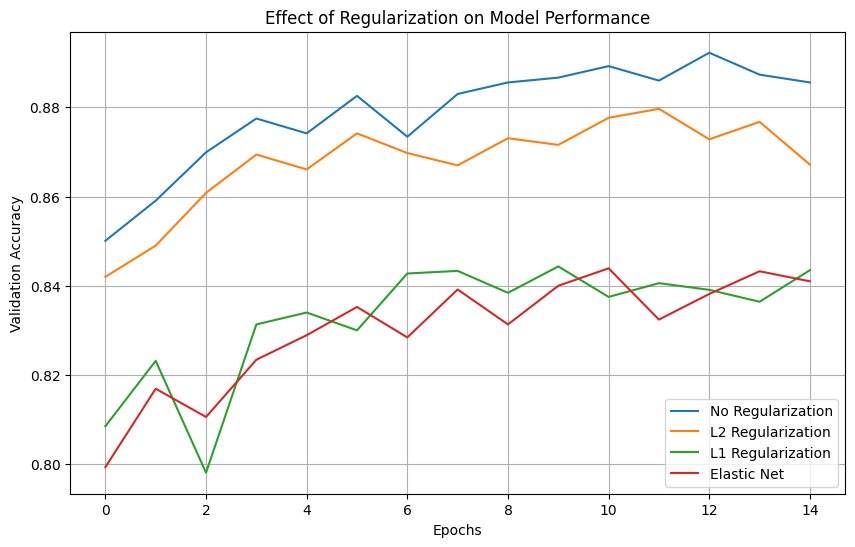

In [10]:
plt.figure(figsize=(10,6))

plt.plot(history_no_reg.history['val_accuracy'], label="No Regularization")
plt.plot(history_l2.history['val_accuracy'], label="L2 Regularization")
plt.plot(history_l1.history['val_accuracy'], label="L1 Regularization")
plt.plot(history_elastic.history['val_accuracy'], label="Elastic Net")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Effect of Regularization on Model Performance")
plt.legend()
plt.grid(True)
plt.show()


Without regularization, the neural network learns overly complex patterns and memorizes the training data, leading to overfitting. Regularization penalizes large weights, forcing the model to learn simpler and more generalizable patterns. L2 stabilizes learning by shrinking weights, L1 introduces sparsity by eliminating less important features, and Elastic Net combines both benefits, resulting in improved generalization performance.